#### Variable Description

$R_c$: Coanda cylinder radius 

$t_u$:  Thickness of upper surface at coanda exit

$t_e$:  Slot opening thickness of coanda

$h_i$:  Plenum height



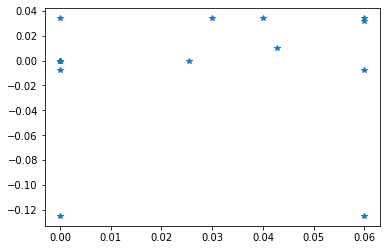

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Control Variables:

Rc = 0.02   # Coanda cylinder radius
te = 0.002  # R/te = 10
tu = 0.002  # Upper surface thickness at exit
ri = 0.02    # Contraction radius inside plenum
ru = 1.0    # Contour radius of upper surface to exit
ai = 60.0   # Contraction angle inside plenum


# Bounding Box:

bU =  0.125 # Upper bound
bD = -0.125 # Lower bound
bL =  0     # Left bound
bR =  0.125 # Right bound
fr =  0.5   # Front bound
bk =  0.5   # Back bound

# Additional Coanda Dimensions:

pl =  0.04  # Plenum internal length
pi =  0.03  # Plenum additional mesh length
pw =  0.008 # Plenum wall thickness

# Mesh expansion for coanda cylinder 

rL = -0.08    
rU =  0.08

# Implicit Dimensions

hi = 2*Rc + te - pw  # Plenum height
le = pl + Rc         # Plenum exit x coordinate
ly = hi - te         # Plenum exit y coordinate


# Fillet calculations:

fil = np.zeros([2,2])

fil[0,0] = le - (np.sin(np.radians(ai)) * (Rc+ri))
fil[0,1] = 0
fil[1,0] = fil[0,0] + (np.sin(np.radians(ai)) * ri)
fil[1,1] = (1-np.cos(np.radians(ai))) * ri



pback = np.zeros([24,2])


# Define Point Matrix:

pback[ 0,:] = np.array([0,0])
pback[ 1,:] = fil[0,:]
pback[ 2,:] = np.array([pi,hi])
pback[ 3,:] = np.array([0,hi])
pback[ 4,:] = fil[1,:]
pback[ 5,:] = np.array([pl,hi])
pback[ 6,:] = np.array([le,ly])
pback[ 7,:] = np.array([le,hi])
pback[ 8,:] = np.array([le,-pw])
pback[ 9,:] = np.array([bL,-pw])
pback[10,:] = np.array([bL,bD])
pback[11,:] = np.array([le,bD])


plt.plot(pback[:,0],pback[:,1],'*')

0.6 0.784003950869444


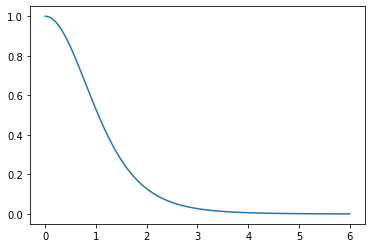

In [50]:
import matplotlib.pyplot as plt

M = np.linspace(0,6,1001)
g = 1.4
prat =1/(1+((g-1)/2)*M**2)**(g/(g-1))

plt.plot(M,prat)

print(M[100],prat[100])

0.3420201433256687
